In [261]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [262]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [263]:
#load mpg dataset
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

In [264]:
df=pd.read_csv(url)

In [265]:
#display first five
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [266]:
#separate input and output
x=df[['displacement']]
y=df['mpg']
#check missing values
print("Missing values in",x.isnull().sum())
print("Missing values in mpg:",y.isnull().sum())

Missing values in displacement    0
dtype: int64
Missing values in mpg: 0


In [267]:
#Remove rows containing missing values
data=df[['displacement','mpg']].dropna()
#update input and output
x=data[['displacement']]
y=data['mpg']
#display selected data
print("Feature:")
print(x.head())

print("\nTarget:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


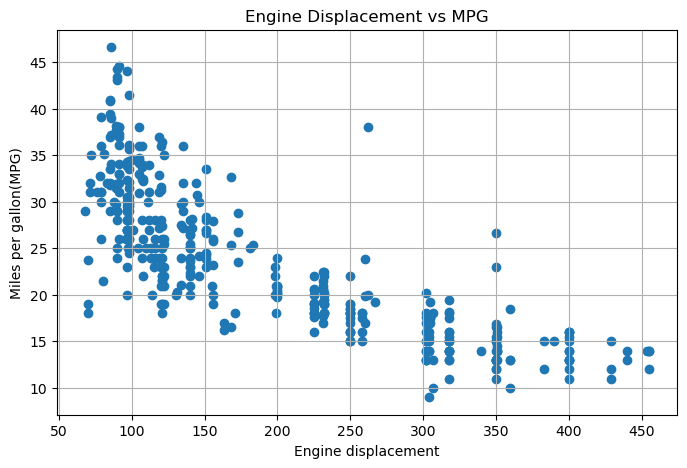

In [268]:
plt.figure(figsize=(8,5))

plt.scatter(x,y)
plt.xlabel("Engine displacement")
plt.ylabel("Miles per gallon(MPG)")
plt.title("Engine Displacement vs MPG")
plt.grid(True)
plt.show()


In [269]:
#split the dataset
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training Samples:",len(x_train))
print("Testing samples:",len(x_test))

Training Samples: 318
Testing samples: 80


In [270]:
#create linear regression model
linear_model=LinearRegression()
#Train the model
linear_model.fit(x_train,y_train)
#Predict on test data
y_pred_linear=linear_model.predict(x_test)

In [271]:
#calculate mse
mse_linear=mean_squared_error(y_test,y_pred_linear)
#calculate r-squared
r2_linear=r2_score(y_test,y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("Mse:",mse_linear)
print("r-squared:",r2_linear)

Linear Regression Results
-------------------------
Mse: 18.102543998358946
r-squared: 0.6633114869465595


In [272]:
#store results
results=[]

#store polynomial models for plotting
# Store the polynomial transformer and trained model
polynomial_models[degree] = {
    'poly': poly,
    'model': poly_model
}

#Add linear regression results
results.append({
   'Model':'Linear Regression',
   'Degree':1,
   'MSE':mse_linear,
   'R-squared':r2_linear
})

#truy ploynomial degrees from 2 to 5
for degree in range(2,6):

     #create polynomila features
     poly=PolynomialFeatures(degree=degree)

     #transform training and testing data
     x_train_poly=poly.fit_transform(x_train)
     x_test_poly=poly.transform(x_test)

     #create linear regression model
     poly_model=LinearRegression()
     #Train polynomial regression model
     poly_model.fit(x_train_poly,y_train)
     #Make predictions
     y_pred_poly=poly_model.predict(x_test_poly)
     #calculate evaluation metrics
     mse=mean_squared_error(y_test,y_pred_poly)
     r2=r2_score(y_test,y_pred_poly)
     #store results
     results.append({
             'Model':'Linear Regression',
             'Degree':degree,
             'MSE':mse,
             'R-squared':r2
     })
    
    
     
    

In [273]:
#convert results into dataframe
result_df=pd.DataFrame(results)
#display results
result_df

,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Linear Regression,2,15.107354,0.719019
2,Linear Regression,3,14.943632,0.722064
3,Linear Regression,4,14.961487,0.721732
4,Linear Regression,5,15.230896,0.716721


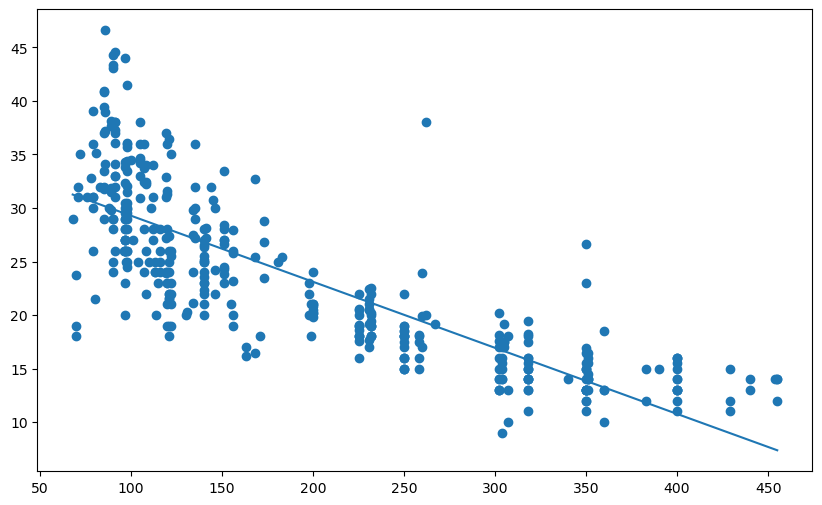

In [274]:
x_plot=pd.DataFrame({
     'displacement':np.linspace(x['displacement'].min(),x['displacement'].max(),300)})
#create figure
plt.figure(figsize=(10,6))
#plot actual data
plt.scatter(
     x['displacement'],
     y,
     label='Actual Data')
y_plot_linear=linear_model.predict(x_plot)
plt.plot(
     x_plot['displacement'],
     y_plot_linear,
     label='Linear Regression'
)


KeyError: 5

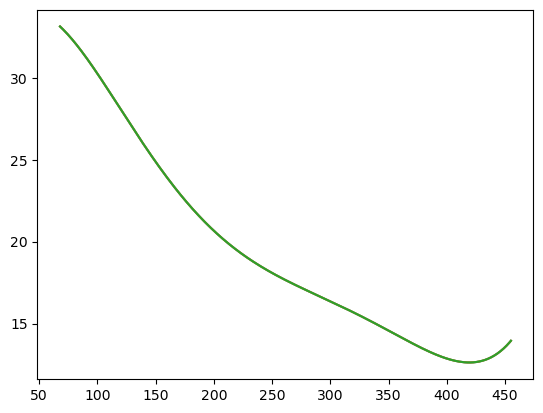

In [275]:
for degree in range(2, 6):
    # Retrieve the stored transformer and model
    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    # Transform the plotting data
    x_plot_poly = poly.transform(x_plot)

    # Predict
    y_plot_poly = poly_model.predict(x_plot_poly)

    # Plot
    plt.plot(
        x_plot['displacement'],
        y_plot_poly,
        label=f'Polynomial Degree {degree}'
    )

plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
bars=plt.bar(
     results_df['Degree'].astype(str),
     results_df['mse']
)
plt.bar_label(bars,fmt='%2.f',padding=3)
plt.xlabel("PolynomialDegree")
plt.ylabel("Mean squared error")
plt.title("Comparison of mse")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()